# Trend Analysis of Flood-Induced Mortality

---
Literature:

Delforge, D., Wathelet, V., Below, R., Sofia, C. L., Tonnelier, M., von Loenhout, J. A. F. and Speybroeck, N. (2025). EM-DAT: the Emergency Events Database. *International Journal of Disaster Risk Reduction, 124*, 1-17. https://doi.org/10.1016/j.ijdrr.2025.105509

Hamed, K. H. and Rao, R. (1997). A modified Mann-Kendall trend test for autocorrelated data. *Journal of Hydrology, 204*, 182-196. https://doi.org/10.1016/S0022-1694(97)00125-X

Hu, P., Zhang, Q., Shi, P, Chen, B. Fang, J. (2018). Flood-induced mortality across the globe: Spatiotemporal pattern and influencing factors. *Science of the Total Environment, 643*, 171-182. https://doi.org/10.1016/j.scitotenv.2018.06.197

Sen, P. K. (1968). Estimates of the Regression Coefficient Based on Kendall's Tau. *Journal of the American Statistical Association, 6*(324), 1379-1389. https://doi.org/10.1080/01621459.1968.10480934 

---

In this notebook, a trend analysis of global floods based on the methodology proposed by Hu et al. (2018) is conducted. Specifically, temporal patterns in global flood occurrences, the number of people affected by floods and flood-induced mortality will be investigated. 

The data is saved under `floods_with_population.csv`, which includes disaster-related data from EM-DAT (Delforge et al., 2025, retrieved on March 4th, 2026 from https://public.emdat.be) as well as demographic data from UNdata (retrieved on March 4th, 2026 from https://data.un.org/Data.aspx?d=POP&f=tableCode%3a1) and Our World in Data (retrieved on March 5th, 2026 from https://ourworldindata.org/grapher/who-regions?tab=table). However, the trend analysis solely utilizes disaster-related data. The variables of interest are summarized below:


| Name                              | Type        | Description                                                                                                                | Source |
|-----------------------------------|-------------|----------------------------------------------------------------------------------------------------------------------------|-------------|
| Disaster Subtype                  | string      | The disaster subtype. Options are 'Flood (General)', 'Flash flood', 'Riverine flood', 'Coastal flood'                      | EM-DAT      |
| Country                           | string      | Country where the disaster occurred and had an impact using names from the UN M49 Standard                                 | EM-DAT      |
| Start Year                        | integer     | Year of occurrence of the disaster                                                                                         | EM-DAT      |
| Start Month                       | float       | Month of occurrence of the disaster                                                                                        | EM-DAT      |
| Start Day                         | float       | Day of occurrence of the disaster                                                                                          | EM-DAT      |
| End Year                          | integer     | Year of conclusion of the disaster                                                                                         | EM-DAT      |
| End Month                         | float       | Month of conclusion of the disaster                                                                                        | EM-DAT      |
| End Day                           | float       | Day of conclusion of the disaster                                                                                          | EM-DAT      |
| Total Damage, Adjusted ('000 US$) | float       | Total Damage (’000 US$) adjusted for inflation using the Consumer Price Index (CPI)                                        | EM-DAT      |
| Total Deaths                      | float       | Total fatalities (deceased and missing combined)                                                                           | EM-DAT      |
| Total Affected                    | float       | Total number of affected people (injured, homeless and/or affected)                                                        | EM-DAT      |

Since the data in EM-DAT has been reported to be particularly biased for disasters prior to 2000 (Delforge et al., 2025), the following analysis exlcusively considers events from 2000 onwards.

## 0. Data loading

In [1]:
# Import models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk

In [2]:
# Load flood data
floods = pd.read_csv("floods_with_population.csv")
floods = floods.rename(columns={"Total Damage, Adjusted ('000 US$)": "Total Damage"})
floods.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4126 entries, 0 to 4125
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Disaster Subtype         4126 non-null   object 
 1   Country                  4126 non-null   object 
 2   Start Year               4126 non-null   int64  
 3   Start Month              4125 non-null   float64
 4   Start Day                3854 non-null   float64
 5   End Year                 4126 non-null   int64  
 6   End Month                4125 non-null   float64
 7   End Day                  3865 non-null   float64
 8   Total Damage             1186 non-null   float64
 9   Total Deaths             3019 non-null   float64
 10  Total Affected           3725 non-null   float64
 11  Population               4029 non-null   float64
 12  WHO Region               4004 non-null   object 
 13  Population (WHO Region)  4004 non-null   float64
dtypes: float64(9), int64(2),

## 1. Floods over Time

To get a first insight into whether flood occurrences and impacts changed over time, we will create a bar plot similar to Fig. 1a) in Hu et al. (2018), who plot the number of floods (globally) against the year in which they occurred. We will create similar plots, for flood count, number of affected people and number of flood-induced deaths per year.

Firstly, the data is grouped by `Start Year` and the number of floods per year is counted and saved under `Number_of_Events`. We also sum up the number of people affected by floods per year (`Total_Affected`) and the number of flood-induced deaths per year (`Total_Deaths`).

Secondly, a plot consisting of three bar plots is created. Each plots one of the three variables created in the first step against `Start Year`.

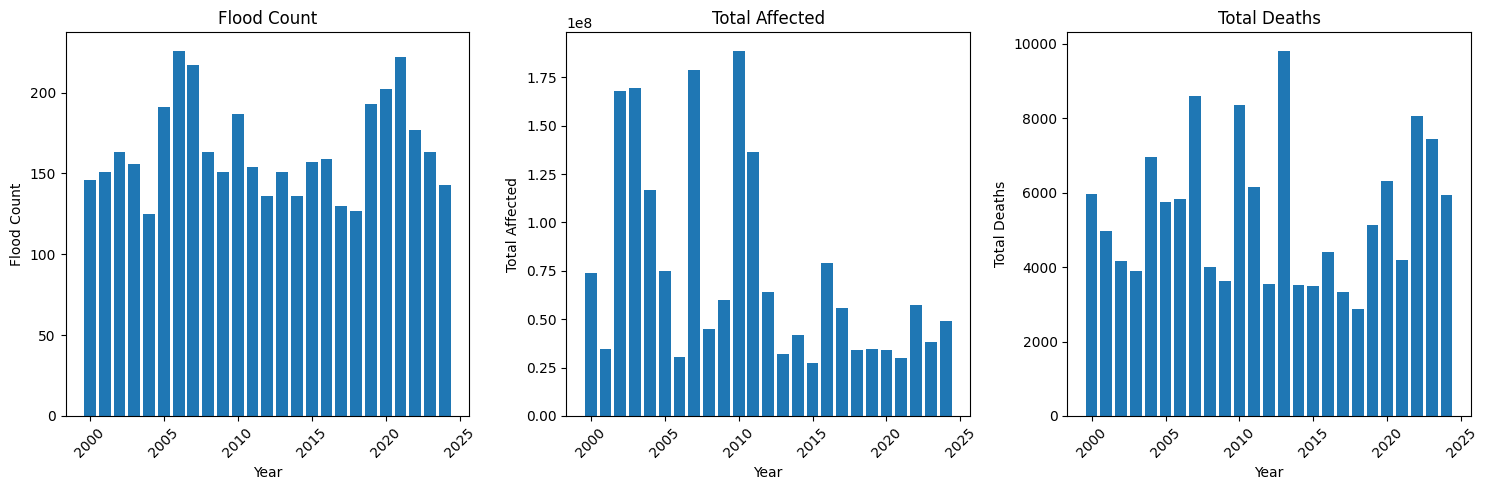

In [3]:
# Group the data
floods_annually = floods.groupby('Start Year', as_index=False
).agg(
    Number_of_Events=('Start Month', 'size'), 
    Total_Affected=('Total Affected', 'sum'),
    Total_Deaths=('Total Deaths', 'sum')
)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

y_vars = ["Number_of_Events", "Total_Affected", "Total_Deaths"]
titles = ["Flood Count", "Total Affected", "Total Deaths"]

for i, ax in enumerate(axes):
    ax.bar(floods_annually["Start Year"], floods_annually[y_vars[i]])
    
    ax.set_xlabel("Year")
    ax.set_ylabel(titles[i])
    ax.set_title(titles[i])
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Based on this plot, it is difficult to observe a clear trend in the flood count, the number of people affected by floods and the number of flood-related deaths over time. Therefore, we will conduct a proper trend analysis in the following section.

## 2. Trend Analysis

Now, we want to formally test whether there is a trend in the three variables of interest (`Number_of_Events`, `Total_Affected`, `Total_Deaths`). In trend analysis, the following null hypothesis is typically tested:
$$H_0: \text{the data are independent and randomly ordered}$$
In other words, the null hypothesis states that there is no trend present in the data. The alternative hypothesis is that there is a (positive or negative) trend present in the data.

Commonly, linear regression models are used to test for trends, i.e.,
$$Y_t = \beta_0 + \beta_1 * t + \varepsilon_t,$$
where $Y_t$ is the outcome variable (such as `Number_of_Events`, `Total_Affected` and `Total_Deaths`), $t = 0, 1, 2, \dots$ is the time index, $\beta_0$ is the intercept, $\beta_1$ is the trend we want to estimate and $\varepsilon_t$ is the error term. However, this model assumes 
$$\varepsilon_t \sim N(0, \sigma^2) \quad \text{i.i.d.},$$
which means that the errors are independent and identically distributed and follow a Gaussian distribution with mean $0$ and variance $\sigma^2$. These assumptions are often violated with meteorological time series data, as they commonly exhibit autocorrelation, which means that the value at time point $t$, $Y_t$, depends on the value at time point $t-1$, $Y_{t-1}$. 

Alternatively, we can test $\text{H}_0$ using the Modified Mann-Kendall (MMK) trend test. The Mann-Kendall test is non-parametric and therefore does not rely on distributional assumptions. We employ a modified version thereof, the MMK trend test, which accounts for autocorrelation (Hamed & Rao, 1997).

### 2.1 Modified Mann-Kendall Test

In this section, the MMK test for `Number_of_Events`, `Total_Affected` and `Total_Deaths` is computed using the function `hamed_rao_modification_test` from the `pymannkendall` package.

In [4]:
mk_count = mk.hamed_rao_modification_test(floods_annually["Number_of_Events"])
mk_affected = mk.hamed_rao_modification_test(floods_annually["Total_Affected"])
mk_deaths = mk.hamed_rao_modification_test(floods_annually["Total_Deaths"])

### 2.2 Trend Significance

Now we can use the p-values obtained from the MMK test from exercise 2.1 to test the null hypothesis,
$$\text{H}_0: \text{no trend is present in the data}$$

Using a significance level of $5\%$, we reject $\text{H}_0$ if the p-values computed with `hamed_rao_modification_test` are strictly smaller that $0.05$.

In [5]:
print(f"P-values: Number of events: {mk_count.p}, total affected: {mk_affected.p}, total_deaths: {mk_deaths.p}")

P-values: Number of events: 0.7787880569154964, total affected: 0.03765485026971738, total_deaths: 0.8436082537436091


We cannot reject the null hypothesis, i.e., that there is no trend, for the flood count and the number of flood-induced deaths, as the respective p-values exceed the 0.05 threshold. However, the p-value for the number of people affected by floods is around 0.038 and thereby smaller than 0.05. Hence, we observe a significant trend in the number of flood-affected people.

### 2.3 Trend Magnitude

While the MMK test allows us to determine whether a statistically significant trend can be observed in the data, it does not yet specifiy the direction or magnitude of this trend. Similarly as Hu et al. (2018), we utilize Sen's slope estimator to quantify the magnitude of the trends for `Number_of_Events`, `Total_Affected` and `Total_Deaths`.

Sen's slope estimator is a robust, non-parametric estimate of the true slope of the trend. Instead of fitting the trend using ordinary least squares, which is sensitive to outliers, Sen's slope estimator computes $\binom{n}{2}$ slopes between all pairs of points. So, for any $i < j$, the slope between the points $(Y_i, t_i)$ and $(Y_j, t_j)$ is given by
$$\frac{Y_j - Y_i}{t_j - t_i}, \quad \forall \ i < j$$

Then, the estimate of the overall slope, $\hat{\beta}_1$ is computed as the median of all pairwise slopes
$$\hat{\beta}_1 = \text{median} \left\{ \frac{Y_j - Y_i}{t_j - t_i} : i < j \right\}$$

The estimate of intercept of the trend line, $\hat{\beta}_0$, is computed so that the trend passes through the "center" of the data:
$$\hat{\beta}_0 = \bar{Y} - \hat{\beta}_1 \bar{t}$$

We now retrieve Sen's slope and intercept estimates, $\hat{\beta}_1$ and $\hat{\beta}_0$,
from the MMK test results of exercise 2.1 for `Number_of_Events`, `Total_Affected` and `Total_Deaths`.

In [6]:
beta0_count = mk_count.intercept
beta1_count = mk_count.slope

beta0_affected = mk_affected.intercept
beta1_affected = mk_affected.slope

beta0_deaths = mk_deaths.intercept
beta1_deaths = mk_deaths.slope

print(f"Intercept estimates: count: {beta0_count}, affected: {beta0_affected}, deaths: {beta0_deaths}")
print(f"Slope estimates: count {beta1_count}, affected: {beta1_affected}, deaths: {beta1_deaths}")

Intercept estimates: count: 154.75824175824175, affected: 82317640.66666666, deaths: 5410.2
Slope estimates: count 0.18681318681318682, affected: -2224818.5555555555, deaths: -22.683333333333334


Sen's slope estimate for the flood count is positive, yet not signifciant, whereas it is negative for the number of affected people and the number of flood-induced deaths.

### 2.4 Plotting the Estimated Trend 

Similarly as in Hu et al. (2018), we now add the estimated trend lines to the figure we created in exercise 1.

The estimated trend lines are given by
$$\hat{y}_t =  \hat{\beta}_0 + \hat{\beta}_1 * t,$$
where $\hat{y}_t$ is the estimated trend of the variable of interest, `Number_of_Events`, `Total_Affected` and `Total_Deaths`, $\hat{\beta}_0$ and $\hat{\beta}_1$ are the Sen's estimates of intercept and slope computed in exercise 2.3, and $t$ is a time index, taking values $0, 1, 2, \dots$

We compute the estimated trend lines for `Number_of_Events`, `Total_Affected` and `Total_Deaths` and add them to the plot created in exercise 1.

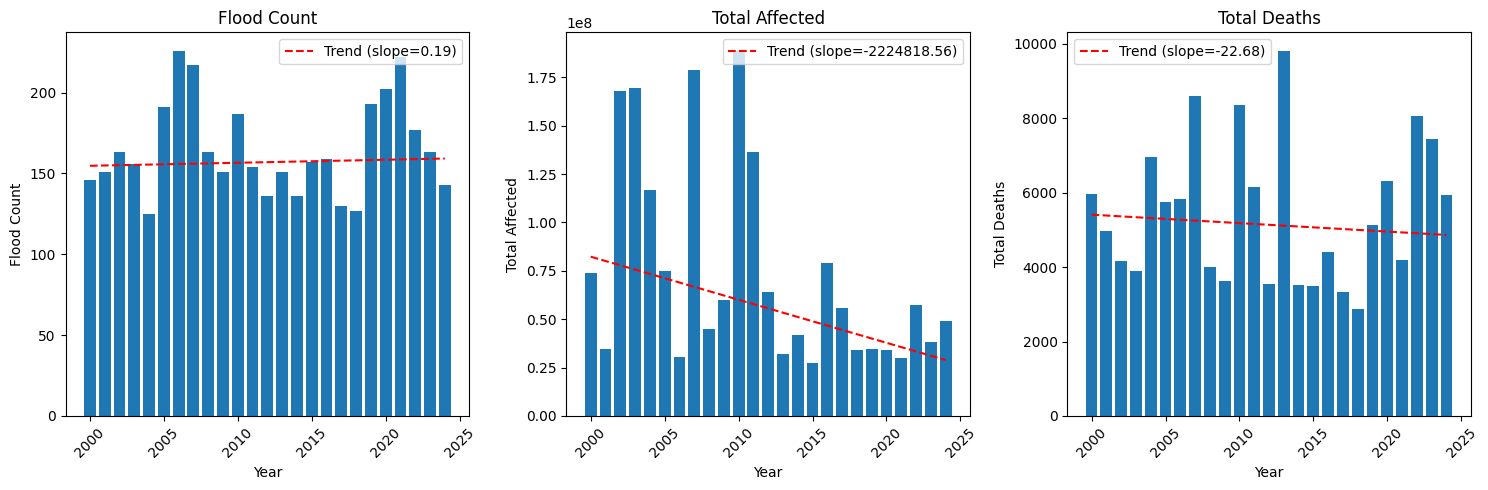

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

y_vars = ["Number_of_Events", "Total_Affected", "Total_Deaths"]
titles = ["Flood Count", "Total Affected", "Total Deaths"]

t = np.arange(len(floods_annually))

mk_results = [mk_count, mk_affected, mk_deaths]

for i, ax in enumerate(axes):
    ax.bar(floods_annually["Start Year"], floods_annually[y_vars[i]])
    
    slope = mk_results[i].slope
    intercept = mk_results[i].intercept
    trend_line = slope * t + intercept
    ax.plot(floods_annually["Start Year"], trend_line, color='red', linestyle='--', label=f"Trend (slope={slope:.2f})")
    ax.legend()
    
    ax.set_xlabel("Year")
    ax.set_ylabel(titles[i])
    ax.set_title(titles[i])
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()